# HOG

## Dataset and preparation

The vehicle images are the Vehicle Type Image Dataset, version 1 (VTID1), by Boonsirisumpun and
Surinta (2021), published on Mendeley Data, doi 10.17632/r7bthvstxw.1. It holds 1 310 colour
photographs in five classes: sedan (400), pickup (478), SUV (129), hatchback (181) and motorcycle
(122). They were taken in daytime by two cameras at the front gate of Loei Rajabhat University in
Thailand, so the viewpoint is fixed and the vehicles are seen from behind, at an angle from above.
The images are cropped around one vehicle and differ in size and aspect ratio.

The images live in `vehicles/r7bthvstxw-1`, one folder per vehicle type. We convert them to
grayscale, resize to 128 x 128 and scale the pixel values to [0, 1]. HOG compares gradients between
images, so they all need the same size for the descriptors to have the same length.

The task asks for at least three images covering simple and complex scenes. We use five. A silhouette
from the scikit-image sample data is the simplest scene possible: one object, a constant background
and no texture. The other four come from our own vehicle dataset and run from one clean scene to a
cluttered one, so the descriptor is also seen on real photographs with background and clutter.

The HOG features are computed with `skimage.feature.hog`, as the task asks. We also wrote the
descriptor ourselves, to make every step visible and to run experiments the library has no options
for, and show that the two give the same result.

Run the cells from the top. The dataset is looked for in this folder and in its parent folders. If
packages are missing, run `%pip install pillow numpy matplotlib scikit-image`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import data

In [2]:
# The dataset is looked for in this folder and in every parent folder, so the notebook runs
# both from the repository and from the folder that holds the data.
# In the group repository the data folder is called "vehicle-type-detection/r7bthvstxw-1".
candidates = [base / folder / "r7bthvstxw-1"
              for base in (Path.cwd(), *Path.cwd().parents)
              for folder in ("vehicles", "vehicle-type-detection")]
data_dir = next((path for path in candidates if path.exists()), None)
if data_dir is None:
    raise FileNotFoundError("Did not find the vehicle dataset (vehicles/r7bthvstxw-1).")

image_size = (128, 128)

# Four vehicle scenes of increasing complexity.
selected = [
    ("Simple: sedan", "sedan/PIC_11.jpg"),
    ("Textured: hatchback", "hatchback/PIC_97.jpg"),
    ("Cluttered: pickup", "pickup/PIC_353.jpg"),
    ("Other shape: motorcycle", "motorcycle/PIC_75.jpg"),
]


def load_grey(path, size=image_size):
    """Load one image as grayscale in [0, 1] and resize it to a common size."""
    with Image.open(path) as image:
        original_size = image.size  # (width, height)
        image = image.convert("L")  # L means grayscale.
        image = image.resize(size)
        return np.asarray(image, dtype=np.float64) / 255.0, original_size


# The simplest scene we can give the descriptor: one object, a constant background and no
# texture. It is the reference point the vehicle images are compared with.
silhouette = Image.fromarray((data.horse() * 255).astype(np.uint8)).resize(image_size)
images = {"Minimal: silhouette": np.asarray(silhouette, dtype=np.float64) / 255.0}
print(f"{'Minimal: silhouette':26s} {'skimage.data.horse()':24s} original "
      f"{data.horse().shape[1]}x{data.horse().shape[0]} -> {image_size[0]}x{image_size[1]}")

for name, relative in selected:
    path = data_dir / relative
    if not path.exists():
        raise FileNotFoundError(f"Did not find {path}")
    images[name], original = load_grey(path)
    print(f"{name:26s} {relative:24s} original {original[0]}x{original[1]} -> {image_size[0]}x{image_size[1]}")

# The image used wherever a single example is enough.
reference_name = "Simple: sedan"

Minimal: silhouette        skimage.data.horse()     original 400x328 -> 128x128
Simple: sedan              sedan/PIC_11.jpg         original 693x448 -> 128x128
Textured: hatchback        hatchback/PIC_97.jpg     original 581x449 -> 128x128
Cluttered: pickup          pickup/PIC_353.jpg       original 701x470 -> 128x128
Other shape: motorcycle    motorcycle/PIC_75.jpg    original 469x727 -> 128x128


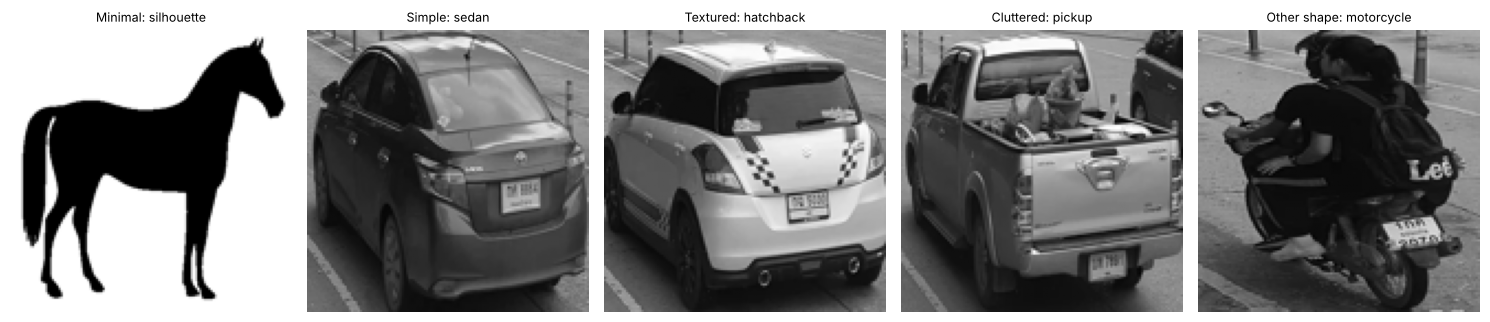

In [3]:
fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 3.2), squeeze=False)

for col, (name, image) in enumerate(images.items()):
    axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].axis("off")

plt.tight_layout()
plt.show()

## HOG Features with scikit-image

The task asks for a script that computes the HOG features of an image with a library. `compute_hog`
below is that script: it calls `skimage.feature.hog` with the settings of Dalal and Triggs, 8 x 8
pixel cells, 2 x 2 cell blocks, 9 orientation bins and L2-Hys block normalisation, and returns both
the descriptor and the HOG image the library draws from it.


In [4]:
from skimage.feature import hog as skimage_hog


def compute_hog(image, cell=8, block=2, bins=9):
    """HOG features of a grayscale image, computed with scikit-image.

    Returns the descriptor as a flat vector and the HOG image drawn by the library.
    """
    descriptor, hog_image = skimage_hog(image, orientations=bins,
                                        pixels_per_cell=(cell, cell),
                                        cells_per_block=(block, block),
                                        block_norm="L2-Hys", visualize=True)
    return descriptor, hog_image


library_features = {}
library_images = {}
print(f"{'Image':26s} {'Length':>7s} {'Mean':>7s} {'Largest value':>14s} {'Values near zero':>17s}")
for name, image in images.items():
    library_features[name], library_images[name] = compute_hog(image)
    descriptor = library_features[name]
    print(f"{name:26s} {descriptor.size:7d} {descriptor.mean():7.3f} {descriptor.max():14.3f} "
          f"{np.mean(descriptor < 0.01):17.1%}")

Image                       Length    Mean  Largest value  Values near zero
Minimal: silhouette           8100   0.045          1.000             85.0%
Simple: sedan                 8100   0.119          0.535             15.0%
Textured: hatchback           8100   0.113          0.662             21.8%
Cluttered: pickup             8100   0.118          0.619             18.7%
Other shape: motorcycle       8100   0.127          0.645             10.1%


## Gradient Computation

HOG is built on the image gradient, using the mask `[-1, 0, 1]` along each axis with no smoothing
first:

$$G_x(x,y) = I(x,y+1) - I(x,y-1), \qquad G_y(x,y) = I(x+1,y) - I(x-1,y)$$

$$m = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \arctan2(G_y, G_x)$$

The direction is used **unsigned**, folded into $[0^\circ, 180^\circ)$, so a light-to-dark edge and
the dark-to-light edge on the other side of the same object fall in the same bin. We test that
choice later.

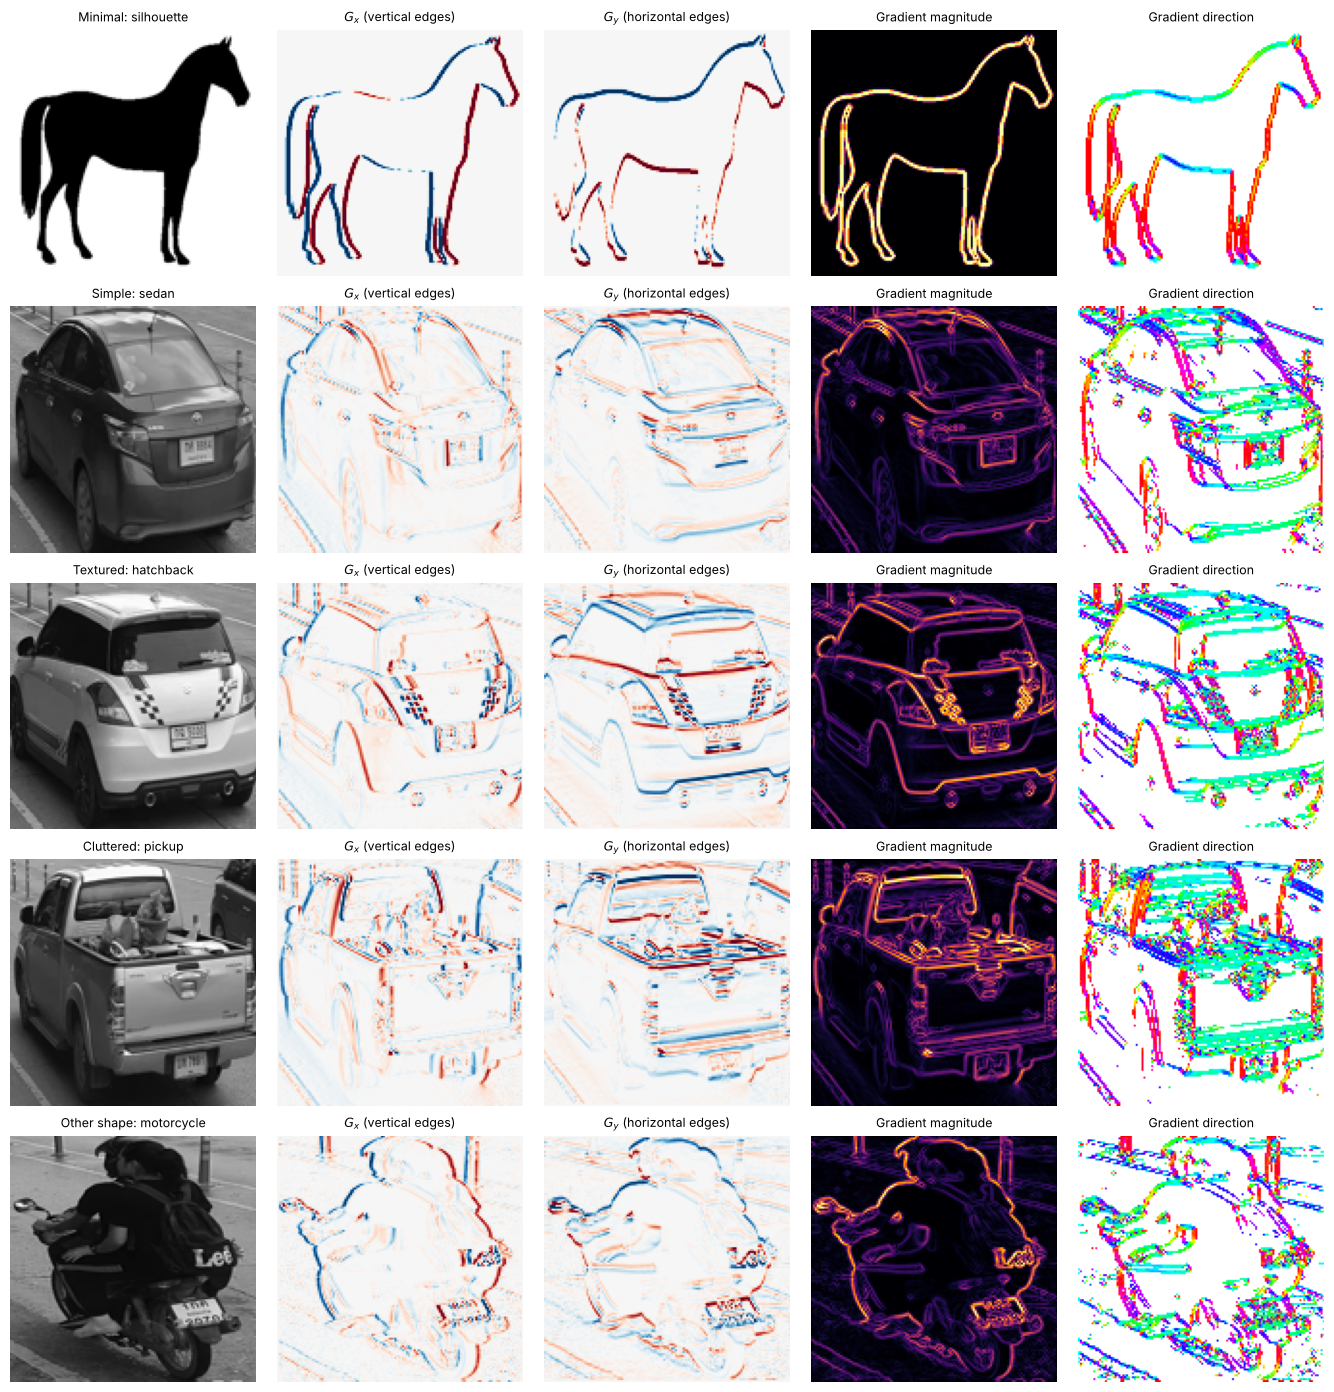

Image                      | Mean gradient  | Pixels with magnitude > 0.08
Minimal: silhouette        |         0.0931 |                           13.1%
Simple: sedan              |         0.0818 |                           30.7%
Textured: hatchback        |         0.1033 |                           33.1%
Cluttered: pickup          |         0.1161 |                           40.7%
Other shape: motorcycle    |         0.0866 |                           29.7%


In [5]:
def blur(image, sigma):
    """Separable Gaussian filter, written with numpy alone."""
    if sigma <= 0:
        return np.asarray(image, dtype=np.float64)
    radius = max(1, int(round(3 * sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-(offsets ** 2) / (2 * sigma ** 2))
    kernel /= kernel.sum()
    result = np.asarray(image, dtype=np.float64)
    for axis in (0, 1):
        padding = [(radius, radius) if a == axis else (0, 0) for a in (0, 1)]
        padded = np.pad(result, padding, mode="edge")
        blurred = np.zeros_like(result)
        for weight, offset in zip(kernel, offsets):
            start = offset + radius
            blurred += weight * (padded[start:start + result.shape[0], :] if axis == 0
                                 else padded[:, start:start + result.shape[1]])
        result = blurred
    return result


def gradients(image, operator="central"):
    """Gradient in x and y. The default is the mask [-1, 0, 1] of Dalal and Triggs.

    The alternatives are only used in the ablation further down: a forward
    difference, a Sobel operator, and the same [-1, 0, 1] applied after a blur.
    """
    image = np.asarray(image, dtype=np.float64)
    if image.ndim != 2:
        raise ValueError("gradients expects a grayscale image (2D)")

    gx = np.zeros_like(image)
    gy = np.zeros_like(image)
    if operator == "forward":
        gx[:, :-1] = image[:, 1:] - image[:, :-1]
        gy[:-1, :] = image[1:, :] - image[:-1, :]
        return gx, gy
    if operator == "sobel":
        # Sobel is [-1, 0, 1] along one axis and the smoothing [1, 2, 1] along the other.
        padded = np.pad(image, 1, mode="edge")
        for dy in (-1, 0, 1):
            weight = 2.0 if dy == 0 else 1.0
            row = padded[1 + dy:1 + dy + image.shape[0], :]
            gx += weight * (row[:, 2:] - row[:, :-2])
        for dx in (-1, 0, 1):
            weight = 2.0 if dx == 0 else 1.0
            col = padded[:, 1 + dx:1 + dx + image.shape[1]]
            gy += weight * (col[2:, :] - col[:-2, :])
        return gx / 4.0, gy / 4.0
    if operator == "blurred":
        image = blur(image, 1.0)
    gx[:, 1:-1] = image[:, 2:] - image[:, :-2]
    gy[1:-1, :] = image[2:, :] - image[:-2, :]
    return gx, gy


def gradient_magnitude_and_angle(image, signed=False, operator="central"):
    """Gradient magnitude and direction. Unsigned folds the direction into [0, 180)."""
    gx, gy = gradients(image, operator)
    span = 360.0 if signed else 180.0
    return np.hypot(gx, gy), np.mod(np.rad2deg(np.arctan2(gy, gx)), span)


fig, axes = plt.subplots(len(images), 5, figsize=(13.5, 2.8 * len(images)), squeeze=False)

for row, (name, image) in enumerate(images.items()):
    gx, gy = gradients(image)
    magnitude, angle = gradient_magnitude_and_angle(image)
    panels = [
        (image, name, dict(cmap="gray", vmin=0, vmax=1)),
        (gx, "$G_x$ (vertical edges)", dict(cmap="RdBu_r", vmin=-0.6, vmax=0.6)),
        (gy, "$G_y$ (horizontal edges)", dict(cmap="RdBu_r", vmin=-0.6, vmax=0.6)),
        (magnitude, "Gradient magnitude", dict(cmap="inferno", vmin=0, vmax=0.8)),
        # Direction is only meaningful where there is an edge, so weak gradients are hidden.
        (np.where(magnitude > 0.08, angle, np.nan), "Gradient direction",
         dict(cmap="hsv", vmin=0, vmax=180)),
    ]
    for ax, (panel, title, options) in zip(axes[row], panels):
        ax.imshow(panel, **options)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

print("Image                      | Mean gradient  | Pixels with magnitude > 0.08")
for name, image in images.items():
    magnitude, _ = gradient_magnitude_and_angle(image)
    print(f"{name:26s} | {magnitude.mean():14.4f} | {np.mean(magnitude > 0.08):31.1%}")

## Our Own Implementation

The library call above answers the task. We also wrote the descriptor ourselves, for two reasons.
Every step becomes visible, which the discussion below relies on, and the experiments need options
`skimage.feature.hog` does not have: signed orientations, other gradient operators and linear voting
between bins. The next section shows that the two implementations agree exactly when they are set up
the same way.

Three steps:

1. **Cells.** Square cells of `cell` x `cell` pixels. Every pixel votes with its gradient
   *magnitude*, split linearly between the two nearest bin centres, wrapping around at both ends.
2. **Blocks.** Overlapping blocks of `block` x `block` cells, stride one cell. Most cells therefore
   appear in several blocks and are normalised differently each time.
3. **Normalisation.** L2-Hys: unit L2 norm, clip at 0.2, renormalise.

Descriptor length:

$$\underbrace{(\lfloor H/c\rfloor - b + 1)(\lfloor W/c\rfloor - b + 1)}_{\text{blocks}}
\times \underbrace{b^2 \times \text{bins}}_{\text{per block}}$$

In [6]:
def hog_cells(image, cell=8, bins=9, signed=False, operator="central", interpolate=True):
    """Orientation histogram per cell, with linear voting between neighbouring bins.

    With interpolate=False every pixel votes for the single bin it falls in. That
    variant is only used to compare with scikit-image, which works that way.
    """
    magnitude, angle = gradient_magnitude_and_angle(image, signed=signed, operator=operator)
    span = 360.0 if signed else 180.0

    height, width = image.shape
    rows, cols = height // cell, width // cell
    if rows < 1 or cols < 1:
        raise ValueError("cell is larger than the image")

    # Split into cells: (rows, cell, cols, cell) -> (rows, cols, cell, cell).
    magnitude = magnitude[:rows * cell, :cols * cell].reshape(rows, cell, cols, cell)
    angle = angle[:rows * cell, :cols * cell].reshape(rows, cell, cols, cell)
    magnitude = magnitude.transpose(0, 2, 1, 3)
    angle = angle.transpose(0, 2, 1, 3)

    # Position between bin centres. The centre of bin b sits at (b + 0.5) * width.
    bin_width = span / bins
    position = angle / bin_width - 0.5
    lower = np.floor(position).astype(int)
    fraction = position - lower
    if not interpolate:
        lower = np.floor(angle / bin_width).astype(int)
        fraction = np.zeros_like(angle)

    histogram = np.zeros((rows, cols, bins))
    for index, weight in ((lower, 1.0 - fraction), (lower + 1, fraction)):
        flat_bin = np.mod(index, bins).reshape(rows * cols, -1).ravel()
        flat_cell = np.arange(rows * cols).repeat(cell * cell)
        np.add.at(histogram.reshape(-1), flat_cell * bins + flat_bin,
                  (magnitude * weight).reshape(rows * cols, -1).ravel())
    return histogram


def hog(image, cell=8, block=2, bins=9, signed=False, eps=1e-6,
        operator="central", norm="L2-Hys", interpolate=True):
    """HOG descriptor: cells, overlapping blocks and block normalisation.

    The defaults are the settings of Dalal and Triggs. `operator` and `norm`
    are only varied in the ablation further down.
    """
    if not all(isinstance(v, (int, np.integer)) and v >= 1 for v in (cell, block, bins)):
        raise ValueError("cell, block and bins must be integers greater than zero.")

    histogram = hog_cells(image, cell=cell, bins=bins, signed=signed, operator=operator,
                          interpolate=interpolate)
    rows, cols, _ = histogram.shape
    if block > min(rows, cols):
        raise ValueError("block is larger than the number of cells.")

    block_rows, block_cols = rows - block + 1, cols - block + 1
    descriptor = np.empty((block_rows, block_cols, block * block * bins))
    for i in range(block_rows):
        for j in range(block_cols):
            v = histogram[i:i + block, j:j + block].ravel()
            if norm == "L1":
                v = v / (v.sum() + eps)
            elif norm == "L1-sqrt":
                v = np.sqrt(v / (v.sum() + eps))
            elif norm == "L2":
                v = v / np.sqrt((v ** 2).sum() + eps ** 2)
            else:                                             # L2-Hys
                v = v / np.sqrt((v ** 2).sum() + eps ** 2)    # L2
                v = np.minimum(v, 0.2)                        # Hys: clip the peaks
                v = v / np.sqrt((v ** 2).sum() + eps ** 2)
            descriptor[i, j] = v
    return descriptor.ravel()


def descriptor_length(shape, cell, block, bins):
    """Descriptor length from the formula above."""
    rows, cols = shape[0] // cell, shape[1] // cell
    return (rows - block + 1) * (cols - block + 1) * block * block * bins

In [7]:
# Check against synthetic edges where the answer is known.
vertical_edge = np.zeros((32, 32))
vertical_edge[:, 16:] = 1.0          # vertical edge -> horizontal gradient, 0 degrees
horizontal_edge = np.zeros((32, 32))
horizontal_edge[16:, :] = 1.0        # horizontal edge -> vertical gradient, 90 degrees
diagonal_edge = np.tril(np.ones((32, 32)))   # 45 degree edge

print("Bin centres (degrees):", np.round((np.arange(9) + 0.5) * 20, 0))
for name, test, cell_index in [("Vertical edge", vertical_edge, (2, 1)),
                               ("Horizontal edge", horizontal_edge, (1, 2)),
                               ("45 degree edge", diagonal_edge, (2, 2))]:
    cell_histogram = hog_cells(test, cell=8, bins=9)[cell_index]
    print(f"{name:16s} {np.round(cell_histogram / cell_histogram.sum(), 3)}")

print(f"\nLength formula: {descriptor_length(image_size, 8, 2, 9)} == "
      f"{hog(np.zeros(image_size)).size}")

Bin centres (degrees): [ 10.  30.  50.  70.  90. 110. 130. 150. 170.]
Vertical edge    [0.5 0.  0.  0.  0.  0.  0.  0.  0.5]
Horizontal edge  [0. 0. 0. 0. 1. 0. 0. 0. 0.]
45 degree edge   [0.   0.   0.   0.   0.   0.   0.75 0.25 0.  ]

Length formula: 8100 == 8100


The synthetic tests behave as the theory predicts. The 45 degree edge has a gradient
perpendicular to it at $135^\circ$, which falls between the bin centres at $130^\circ$ and
$150^\circ$; the vote splits 0.75 / 0.25 and recovers exactly $135^\circ$. The vertical edge splits
evenly between the first and last bin, which confirms that the wrap-around works.

## Comparison with scikit-image

Our own descriptor is compared with the library result from `compute_hog`, on the same images and
with the same settings.


In [8]:
def cosine_similarity(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


print(f"{'Image':26s} {'ours':>7s} {'skimage':>8s} {'cosine, linear voting':>22s} {'cosine, single bin':>19s}")
for name, image in images.items():
    ours = hog(image, cell=8, block=2, bins=9)
    single_bin = hog(image, cell=8, block=2, bins=9, interpolate=False)
    theirs = library_features[name]
    print(f"{name:26s} {ours.size:7d} {theirs.size:8d} {cosine_similarity(ours, theirs):22.4f} "
          f"{cosine_similarity(single_bin, theirs):19.4f}")


Image                         ours  skimage  cosine, linear voting  cosine, single bin
Minimal: silhouette           8100     8100                 0.9444              1.0000
Simple: sedan                 8100     8100                 0.9855              1.0000
Textured: hatchback           8100     8100                 0.9812              1.0000
Cluttered: pickup             8100     8100                 0.9858              1.0000
Other shape: motorcycle       8100     8100                 0.9841              1.0000


The two descriptors have identical length, and the difference between them is fully explained by one
design choice. `skimage` assigns each pixel to the single orientation bin it falls in, where we
split the vote linearly between the two nearest bins as Dalal and Triggs describe. With our own
voting switched to a single bin the cosine similarity is 1.0000 on all five images, so gradients,
cells, blocks and normalisation agree exactly. With linear voting it is 0.981 to 0.986 on the
vehicle images and 0.944 on the silhouette, where nearly all the energy sits on a thin outline and
the difference in voting is not averaged out by texture.


## Visualization

The task asks for the original image, the gradient image and the HOG feature image. The third column
is the HOG image returned by scikit-image. The fourth is our own drawing of the same cell
histograms on top of the image, so it is easier to see which structure each cell responds to. In
both, each cell is drawn as a star of line segments, one per orientation bin, with length
proportional to the bin weight, and the segments are drawn perpendicular to the gradient so they
follow the edge.


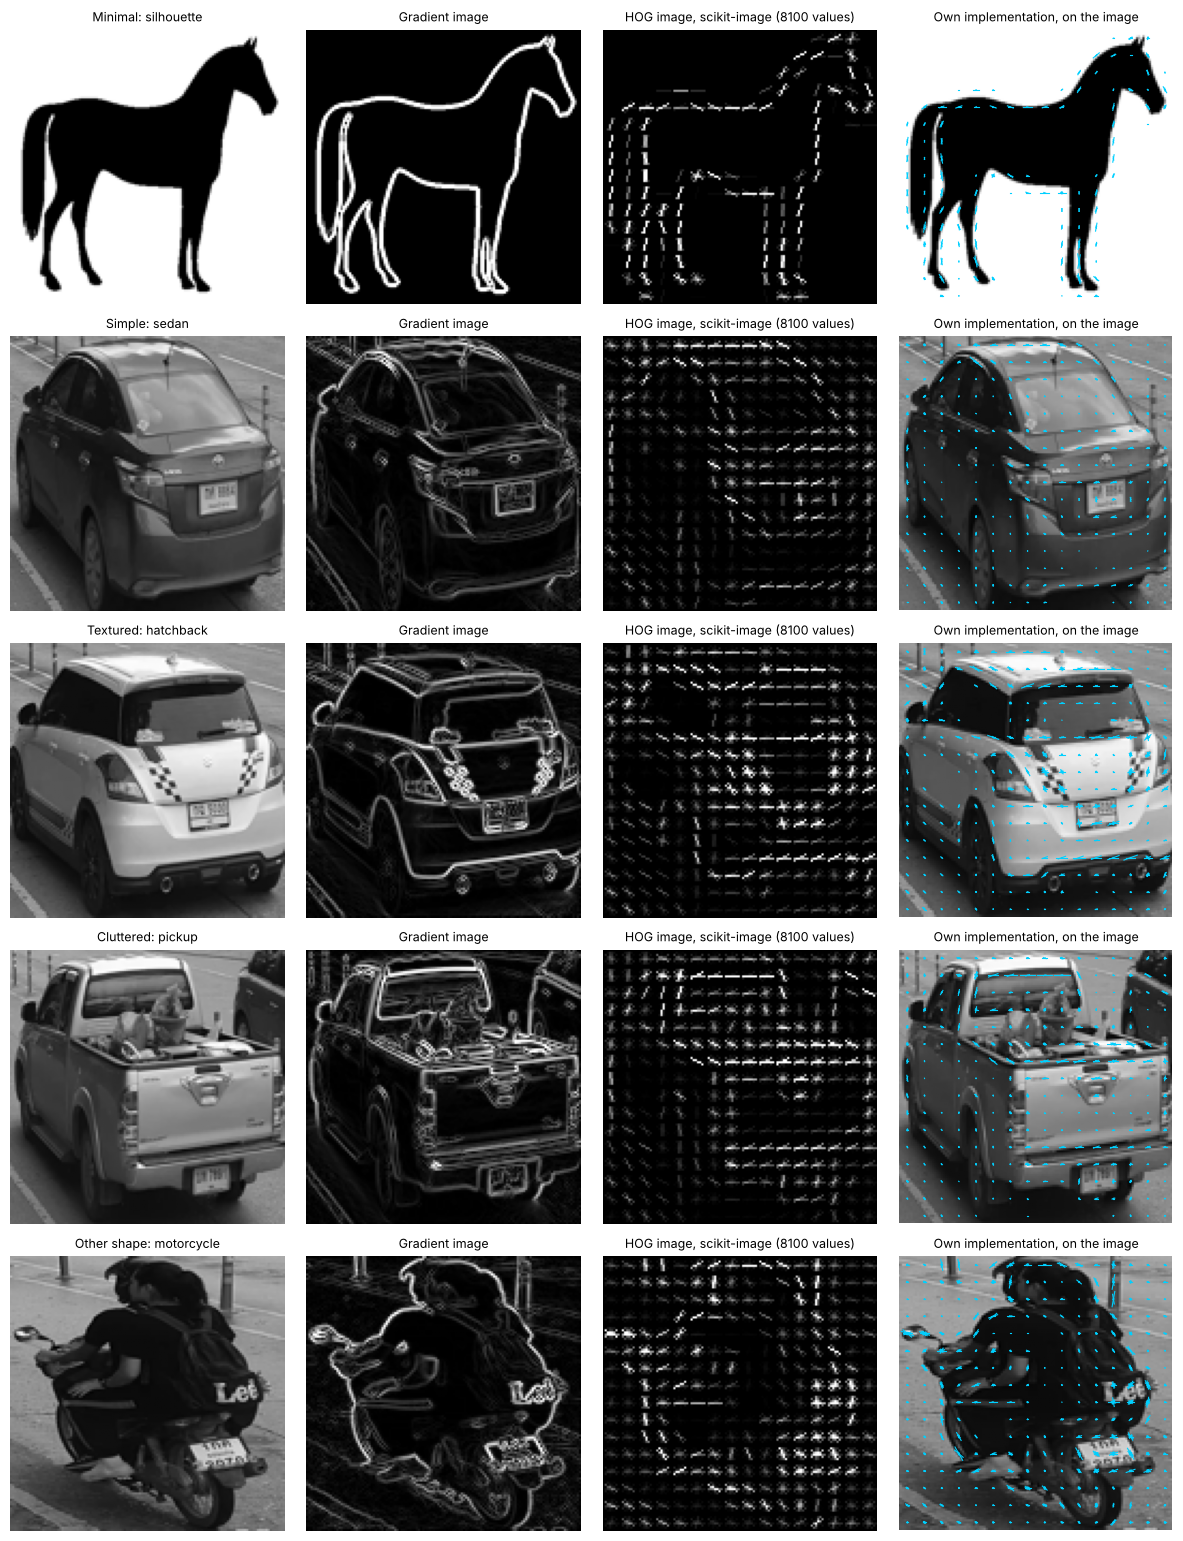

In [9]:
def draw_hog(cell_histogram, cell, ax, scale=0.9, color="#00d0ff"):
    """Draw one star per cell on top of the image already in ax."""
    rows, cols, bins = cell_histogram.shape
    peak = cell_histogram.max() or 1.0
    angles = (np.arange(bins) + 0.5) * (np.pi / bins)

    for i in range(rows):
        for j in range(cols):
            center_y, center_x = (i + 0.5) * cell, (j + 0.5) * cell
            for b, angle in enumerate(angles):
                length = scale * 0.5 * cell * cell_histogram[i, j, b] / peak
                if length < 0.05:
                    continue
                # The edge is perpendicular to the gradient, hence cos/-sin.
                dy, dx = length * np.cos(angle), -length * np.sin(angle)
                ax.plot([center_x - dx, center_x + dx], [center_y - dy, center_y + dy],
                        color=color, linewidth=0.8)
    ax.set_xlim(0, cols * cell)
    ax.set_ylim(rows * cell, 0)


fig, axes = plt.subplots(len(images), 4, figsize=(12, 3.1 * len(images)), squeeze=False)

features = {}
for row, (name, image) in enumerate(images.items()):
    magnitude, _ = gradient_magnitude_and_angle(image)
    features[name] = hog(image)

    axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(name, fontsize=9)

    axes[row, 1].imshow(magnitude, cmap="gray", vmin=0, vmax=0.8)
    axes[row, 1].set_title("Gradient image", fontsize=9)

    # The library image is dominated by a few strong cells, so the display range is cut at 40 %.
    axes[row, 2].imshow(library_images[name], cmap="gray", vmax=0.4 * library_images[name].max())
    axes[row, 2].set_title(f"HOG image, scikit-image ({len(library_features[name])} values)",
                           fontsize=9)

    axes[row, 3].imshow(image, cmap="gray", vmin=0, vmax=1)
    draw_hog(hog_cells(image, cell=8, bins=9), 8, axes[row, 3])
    axes[row, 3].set_title("Own implementation, on the image", fontsize=9)

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

### What the visualisation shows

Share of pixels above the gradient threshold: silhouette 13.1 %, simple 30.7 %, textured 33.1 %,
cluttered 40.7 %, motorcycle 29.7 %.

The **silhouette** has a gradient on its outline and nowhere else. Its HOG image is a chain of
segments that follows the contour of the horse, with empty cells inside the body and across the
background. This is the descriptor doing exactly what it was designed for: a shape drawn by the
direction of its boundary.

In the **vehicle images** the outline is still there, but so is everything else. The chequered
decal, the load on the pickup bed and the vehicles in the background raise the share of edge pixels
without saying anything about the target, and HOG has no segmentation step to separate them. Road
texture gives short segments in almost every cell.

The four vehicle images all peak in the bin centred at 90 degrees. That is the direction of the
*gradient*, so it corresponds to **horizontal** edges, as the synthetic test above showed: bumpers,
rooflines, tailgates, number plates and the road markings behind the vehicle. The orientation
profile alone therefore does not separate the vehicle classes; it is *where* the directions occur
that carries the information, which is what the cell grid encodes. The comparison below puts numbers
on both.


## Block Normalisation

Block normalisation is the step that is easiest to leave out and hardest to justify from a picture,
so we test it directly. Three changes are applied to the same image and the descriptor is compared
with the original by cosine similarity, once with L2-Hys blocks and once using the raw cell
histograms:

* a **global** intensity change, the same everywhere;
* a **gamma** change, monotone but non-linear;
* a **vignette**, a multiplier rising from left to right, which changes contrast *differently in
  different parts of the image*.

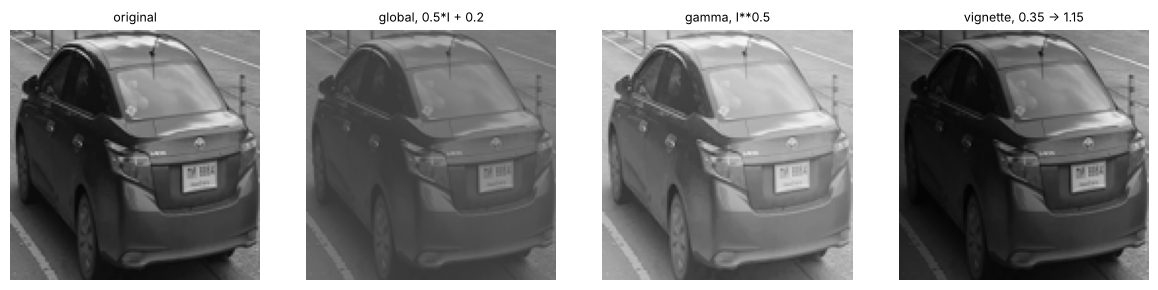

Change                      With L2-Hys blocks   Raw cell histograms
global, 0.5*I + 0.2                     1.0000                1.0000
gamma, I**0.5                           0.9957                0.9738
vignette, 0.35 -> 1.15                  0.9918                0.9620


In [10]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


name = reference_name
base = images[name]
h, w = base.shape
vignette = np.linspace(0.35, 1.15, w)[None, :] * np.ones((h, 1))

variants = {
    "global, 0.5*I + 0.2": np.clip(0.5 * base + 0.2, 0, 1),
    "gamma, I**0.5": base ** 0.5,
    "vignette, 0.35 -> 1.15": np.clip(base * vignette, 0, 1),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 2.9), squeeze=False)
axes[0, 0].imshow(base, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("original", fontsize=9)
for ax, (label, variant) in zip(axes[0, 1:], variants.items()):
    ax.imshow(variant, cmap="gray", vmin=0, vmax=1)
    ax.set_title(label, fontsize=9)
for ax in axes[0]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"{'Change':26s} {'With L2-Hys blocks':>19s} {'Raw cell histograms':>21s}")
for label, variant in variants.items():
    with_blocks = cosine(hog(base), hog(variant))
    cells_only = cosine(hog_cells(base, cell=8, bins=9).ravel(),
                        hog_cells(variant, cell=8, bins=9).ravel())
    print(f"{label:26s} {with_blocks:19.4f} {cells_only:21.4f}")

A global intensity change is handled perfectly **with or without** blocks, both cosines are exactly
1.0000. That is worth stating because it is often presented as the benefit of block normalisation,
and this test cannot credit it to the blocks: `[-1, 0, 1]` is linear, so scaling the whole image
scales every gradient by the same factor, and a cosine similarity is scale invariant by
construction. A distance that is not scale invariant, such as the Euclidean, would separate the raw
histograms, but a single global normalisation would repair that just as well as local blocks do.

Non-uniform illumination is where normalisation earns its place. Under the vignette the
block-normalised descriptor keeps a cosine of 0.9918 while the raw cell histograms drop to 0.9620,
so the deviation falls from 0.0380 to 0.0082, a reduction of 78 %. The mechanism is local: each
block divides by its own norm, so a block in the dark left part of the image is rescaled by a
different amount than one on the bright right, and the differences largely cancel. This is also the
reason the block size matters at all, which the parameter study below measures.

## Comparing the Images

The **orientation profile** sums the descriptor per bin and shows which edge directions dominate.
The **cosine similarity** between two full descriptors is 1 when they point the same way.

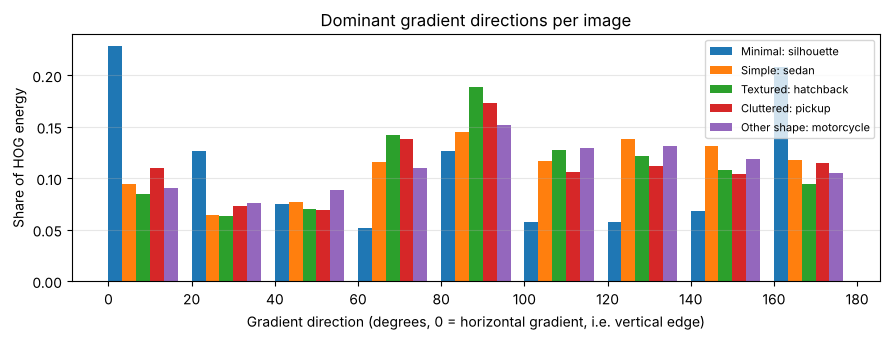

In [11]:
def orientation_profile(descriptor, bins=9):
    """Share of the HOG energy per orientation bin."""
    profile = descriptor.reshape(-1, bins).sum(axis=0)
    return profile / profile.sum()


names = list(features)
bins = 9
centers = (np.arange(bins) + 0.5) * 180 / bins

fig, ax = plt.subplots(figsize=(9, 3.5))
width = 180 / bins / (len(names) + 1)
for i, name in enumerate(names):
    ax.bar(centers + (i - len(names) / 2) * width, orientation_profile(features[name]),
           width=width, label=name)
ax.set(xlabel="Gradient direction (degrees, 0 = horizontal gradient, i.e. vertical edge)",
       ylabel="Share of HOG energy",
       title="Dominant gradient directions per image")
ax.set_xticks(np.arange(0, 181, 20))
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

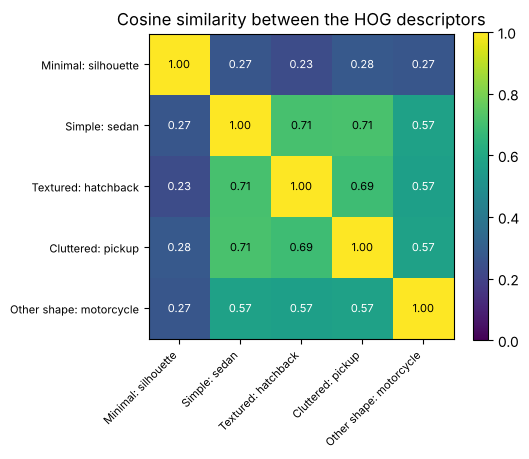

Cosine similarity
  Minimal: silhouette        vs Simple: sedan              0.268
  Minimal: silhouette        vs Textured: hatchback        0.233
  Minimal: silhouette        vs Cluttered: pickup          0.280
  Minimal: silhouette        vs Other shape: motorcycle    0.268
  Simple: sedan              vs Textured: hatchback        0.708
  Simple: sedan              vs Cluttered: pickup          0.715
  Simple: sedan              vs Other shape: motorcycle    0.572
  Textured: hatchback        vs Cluttered: pickup          0.689
  Textured: hatchback        vs Other shape: motorcycle    0.565
  Cluttered: pickup          vs Other shape: motorcycle    0.574

Statistics per image
Minimal: silhouette        length=8100  mean=0.050  share near zero=81.1%  strongest direction=10 degrees
Simple: sedan              length=8100  mean=0.123  share near zero=11.5%  strongest direction=90 degrees
Textured: hatchback        length=8100  mean=0.118  share near zero=17.7%  strongest direction=90 

In [12]:
# Cosine similarity between the descriptors.
F = np.array([features[name] for name in names])
F = F / np.linalg.norm(F, axis=1, keepdims=True)
similarity = F @ F.T

fig, ax = plt.subplots(figsize=(5.5, 4.6))
image_handle = ax.imshow(similarity, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{similarity[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if similarity[i, j] < 0.6 else "black")
ax.set_title("Cosine similarity between the HOG descriptors")
fig.colorbar(image_handle, ax=ax)
plt.tight_layout()
plt.show()

print("Cosine similarity")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        print(f"  {names[i]:26s} vs {names[j]:26s} {similarity[i, j]:.3f}")

print("\nStatistics per image")
for name in names:
    descriptor = features[name]
    profile = orientation_profile(descriptor)
    print(f"{name:26s} length={len(descriptor)}  mean={descriptor.mean():.3f}  "
          f"share near zero={np.mean(descriptor < 0.01):.1%}  "
          f"strongest direction={centers[profile.argmax()]:.0f} degrees")

### What the comparison shows

**The orientation profile separates the silhouette from the photographs, and barely separates the
photographs from each other.** A uniform profile would put 11.1 % in every bin. The silhouette puts
44 % of its energy in the two bins next to 0 and 180 degrees, which are vertical edges: the legs,
the neck and the rump. The four vehicles all peak at 90 degrees instead, horizontal edges, and are
weakest at 30 to 50 degrees. Among them the two boxy rear views concentrate the most: the hatchback
has 18.9 % in the 90 degree bin and the pickup 17.3 %, from the tailgate, bumper and roof edge. The
sedan (14.5 %) and the motorcycle (15.1 %) are flatter and carry more at 110 to 170 degrees, the
sloping rear window and boot line on the sedan and the rounded outline of the riders on the
motorcycle. The largest difference between two vehicles in any bin is under five percentage points.

**The full descriptors separate by layout, not by clutter.** The silhouette has a cosine similarity
of 0.23 to 0.28 with every vehicle. The three cars agree at 0.69 to 0.72 with each other, and the
motorcycle at 0.57 with each of them. The vehicle profiles are nearly the same, so that drop comes
from *where* the edges are: the cars share a rear-view layout with the horizontal structure in the
same cells, and the upright motorcycle does not. The simple sedan is no closer to the hatchback
(0.708) than to the cluttered pickup (0.715), so the decal, the load and the background vehicle
change the descriptor less than a change of object shape does.

**A simple scene leaves most of the descriptor empty; a photograph leaves almost none of it empty.**
81.1 % of the silhouette's values are near zero (below 0.01), against 7 to 18 % for the vehicles, and its mean
value is 0.050 against about 0.12. The reason is block normalisation. A block over a perfectly
constant background has nothing to normalise and stays at zero. A block over road surface contains
only weak texture and sensor noise, but it is rescaled to unit norm like every other block, so that
noise is stretched to the same scale as a real edge elsewhere. In a photograph the descriptor
therefore never says "nothing here", only which direction the weak structure has. That is why the
near-zero share does not follow the clutter ordering among the vehicles, and why the mean value is
the same for all four whatever their gradient energy.

These are five images, so this shows what the descriptor responds to, not that the vehicle classes
can be told apart. The parameter study below asks that on 200 images, and there the difference
between same-class and different-class similarity is about 0.03, far smaller than the 0.13 that
separates the cars from the motorcycle here.


## Experimentation

We measure the three parameters instead of only discussing them. 40 images per class are encoded
with each setting, and we report:

* the **cosine gap**: mean similarity within a class minus mean similarity between classes;
* **leave-one-out 1-NN accuracy**; chance is 0.200 on a balanced set.

This is not meant as a finished classifier, only as a way of asking which settings carry more class
information.

In [13]:
def list_images(class_dir):
    """All JPEG files in a folder, in the same order on every operating system.

    A glob for "*.jpg" plus "*.JPG" returns every file twice on Windows, where
    file names are not case sensitive, so the suffix is compared in lower case.
    """
    return sorted((p for p in class_dir.iterdir() if p.suffix.lower() in (".jpg", ".jpeg")),
                  key=lambda p: p.name.lower())


rng = np.random.default_rng(0)
per_class = 40

subset_images = []
subset_labels = []
subset_paths = []
subset_aspect = []      # width / height of the original file
for class_dir in sorted((p for p in data_dir.iterdir() if p.is_dir()), key=lambda p: p.name):
    paths = list_images(class_dir)
    chosen = rng.choice(len(paths), min(per_class, len(paths)), replace=False)
    for index in sorted(chosen):
        grey, original = load_grey(paths[index])
        subset_images.append(grey)
        subset_labels.append(class_dir.name)
        subset_paths.append(paths[index])
        subset_aspect.append(original[0] / original[1])

subset_images = np.array(subset_images)
subset_labels = np.array(subset_labels)
subset_aspect = np.array(subset_aspect)
print(f"Loaded {len(subset_images)} images for the parameter study.")
for label in np.unique(subset_labels):
    print(f"{label}: {np.sum(subset_labels == label)} images")

Loaded 200 images for the parameter study.
hatchback: 40 images
motorcycle: 40 images
pickup: 40 images
sedan: 40 images
suv: 40 images


In [14]:
def encode(**parameters):
    return np.stack([hog(image, **parameters) for image in subset_images])


similarities = {}      # cosine similarity matrix per setting, reused by the bootstrap below


def evaluate(descriptors, name=None):
    """Cosine gap and leave-one-out 1-NN accuracy."""
    normalised = descriptors / np.linalg.norm(descriptors, axis=1, keepdims=True)
    similarity = normalised @ normalised.T
    if name is not None:
        similarities[name] = similarity.copy()

    same_class = subset_labels[:, None] == subset_labels[None, :]
    diagonal = np.eye(len(subset_labels), dtype=bool)
    within = similarity[same_class & ~diagonal].mean()
    between = similarity[~same_class].mean()

    np.fill_diagonal(similarity, -2.0)   # an image cannot be its own neighbour
    predicted = subset_labels[similarity.argmax(axis=1)]
    return within - between, (predicted == subset_labels).mean(), predicted


settings = [("Cell size", 4, dict(cell=4, block=2, bins=9)),
            ("Cell size", 8, dict(cell=8, block=2, bins=9)),
            ("Cell size", 16, dict(cell=16, block=2, bins=9)),
            ("Cell size", 32, dict(cell=32, block=2, bins=9)),
            ("Block size", 1, dict(cell=8, block=1, bins=9)),
            ("Block size", 2, dict(cell=8, block=2, bins=9)),
            ("Block size", 3, dict(cell=8, block=3, bins=9)),
            ("Bins", 4, dict(cell=8, block=2, bins=4)),
            ("Bins", 9, dict(cell=8, block=2, bins=9)),
            ("Bins", 12, dict(cell=8, block=2, bins=12)),
            ("Bins", 18, dict(cell=8, block=2, bins=18))]

results = []
predictions = {}
for group, value, parameters in settings:
    descriptors = encode(**parameters)
    gap, accuracy, predicted = evaluate(descriptors, (group, value))
    predictions[(group, value)] = predicted
    results.append((group, value, descriptors.shape[1], gap, accuracy))

print(f"{'Parameter':16s} {'Value':>6s} {'Length':>8s} {'Gap':>7s} {'1-NN':>7s}")
previous = None
for group, value, length, gap, accuracy in results:
    if group != previous:
        print("-" * 48)
        previous = group
    print(f"{group:16s} {value:6d} {length:8d} {gap:7.3f} {accuracy:7.3f}")

Parameter         Value   Length     Gap    1-NN
------------------------------------------------
Cell size             4    34596   0.020   0.750
Cell size             8     8100   0.027   0.745
Cell size            16     1764   0.030   0.790
Cell size            32      324   0.019   0.765
------------------------------------------------
Block size            1     2304   0.015   0.760
Block size            2     8100   0.027   0.745
Block size            3    15876   0.033   0.775
------------------------------------------------
Bins                  4     3600   0.016   0.745
Bins                  9     8100   0.027   0.745
Bins                 12    10800   0.028   0.755
Bins                 18    16200   0.030   0.760


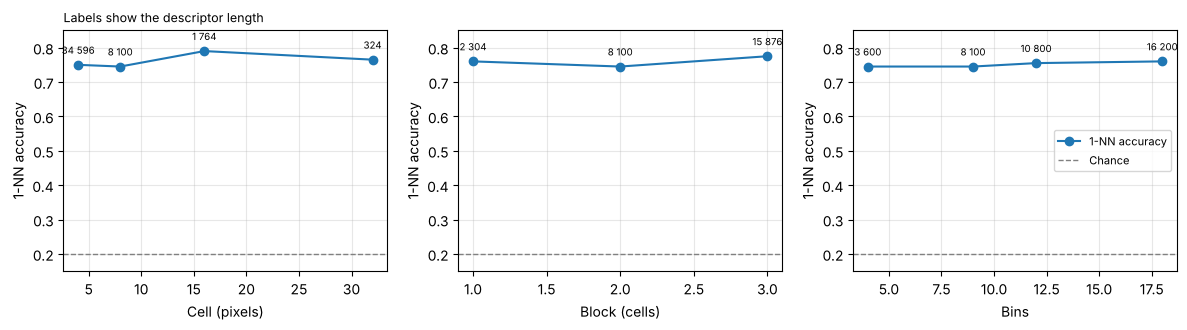

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), squeeze=False)

for ax, group, xlabel in zip(axes[0], ["Cell size", "Block size", "Bins"],
                             ["Cell (pixels)", "Block (cells)", "Bins"]):
    rows = [r for r in results if r[0] == group]
    values = [r[1] for r in rows]
    ax.plot(values, [r[4] for r in rows], "o-", color="tab:blue", label="1-NN accuracy")
    ax.axhline(0.2, color="gray", linestyle="--", linewidth=1, label="Chance")
    for value, _, length, _, accuracy in [(r[1], r[2], r[2], r[3], r[4]) for r in rows]:
        ax.annotate(f"{length:,}".replace(",", " "), (value, accuracy),
                    textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center")
    ax.set(xlabel=xlabel, ylabel="1-NN accuracy", ylim=(0.15, 0.85))
    ax.grid(alpha=0.3)
axes[0, 0].set_title("Labels show the descriptor length", fontsize=9, loc="left")
axes[0, 2].legend(fontsize=8)
plt.tight_layout()
plt.show()

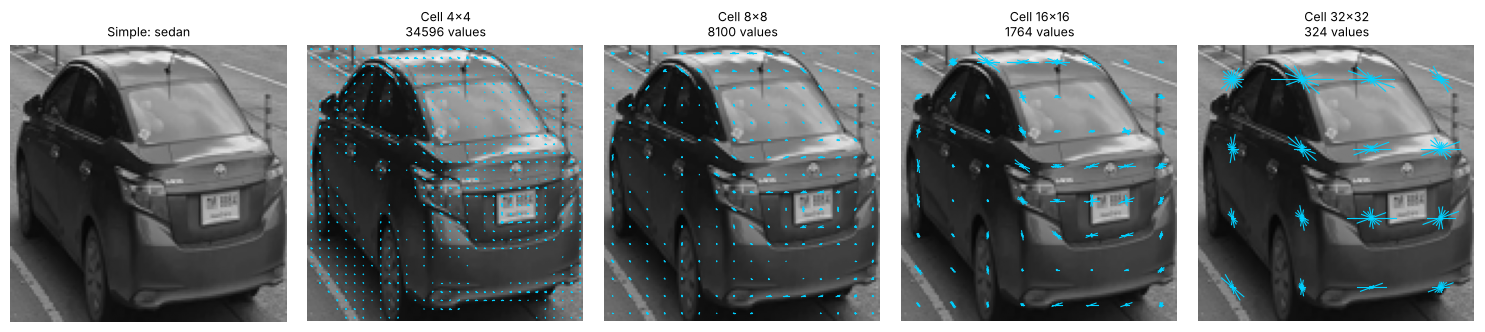

In [16]:
# How does the descriptor look at different cell sizes?
name = reference_name
cell_sizes = [4, 8, 16, 32]
fig, axes = plt.subplots(1, len(cell_sizes) + 1, figsize=(3 * (len(cell_sizes) + 1), 3.2),
                         squeeze=False)

axes[0, 0].imshow(images[name], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title(name, fontsize=9)
for col, cell in enumerate(cell_sizes, start=1):
    axes[0, col].imshow(images[name], cmap="gray", vmin=0, vmax=1)
    draw_hog(hog_cells(images[name], cell=cell, bins=9), cell, axes[0, col])
    axes[0, col].set_title(f"Cell {cell}x{cell}\n{descriptor_length(image_size, cell, 2, 9)} values",
                           fontsize=9)
for ax in axes[0]:
    ax.axis("off")

plt.tight_layout()
plt.show()

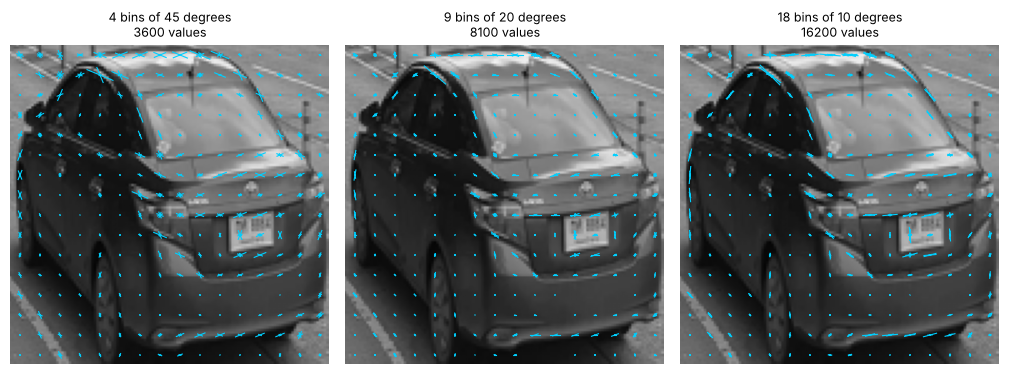

 Block  Blocks  Values per block  Length  Uses of an interior cell
     1     256                 9    2304                         1
     2     225                36    8100                         4
     3     196                81   15876                         9


In [17]:
# And with different numbers of orientation bins?
bin_counts = [4, 9, 18]
fig, axes = plt.subplots(1, len(bin_counts), figsize=(3.4 * len(bin_counts), 3.7), squeeze=False)

for ax, n_bins in zip(axes[0], bin_counts):
    ax.imshow(images[name], cmap="gray", vmin=0, vmax=1)
    draw_hog(hog_cells(images[name], cell=8, bins=n_bins), 8, ax, scale=1.4)
    ax.set_title(f"{n_bins} bins of {180 / n_bins:.0f} degrees\n"
                 f"{descriptor_length(image_size, 8, 2, n_bins)} values", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Block size changes how often a cell is used, not what it looks like.
cells_per_side = image_size[0] // 8
print(f"{'Block':>6s} {'Blocks':>7s} {'Values per block':>17s} {'Length':>7s} {'Uses of an interior cell':>25s}")
for block in (1, 2, 3):
    blocks = (cells_per_side - block + 1) ** 2
    print(f"{block:6d} {blocks:7d} {block * block * 9:17d} "
          f"{descriptor_length(image_size, 8, block, 9):7d} {block * block:25d}")

In [18]:
# Is it worth keeping the sign of the gradient direction?
for signed in (False, True):
    descriptors = encode(cell=8, block=2, bins=9, signed=signed)
    gap, accuracy, _ = evaluate(descriptors, ("Signed", signed))
    label = "signed [0, 360)" if signed else "unsigned [0, 180)"
    print(f"{label:20s} length={descriptors.shape[1]:6d}  gap={gap:.3f}  1-NN={accuracy:.3f}")

# Accuracy per class for the baseline cell size and the coarsest one.
print("\nAccuracy per class")
for value in (8, 32):
    predicted = predictions[("Cell size", value)]
    per_label = "  ".join(f"{label} {np.mean(predicted[subset_labels == label] == label):.2f}"
                          for label in np.unique(subset_labels))
    print(f"  cell {value:2d}: {per_label}")

unsigned [0, 180)    length=  8100  gap=0.027  1-NN=0.745
signed [0, 360)      length=  8100  gap=0.024  1-NN=0.735

Accuracy per class
  cell  8: hatchback 0.50  motorcycle 0.85  pickup 0.80  sedan 0.85  suv 0.72
  cell 32: hatchback 0.50  motorcycle 1.00  pickup 0.75  sedan 0.85  suv 0.72


### Are the differences real?

200 images means one image is half a percentage point. The two settings are compared on the same
images, so the right check is McNemar's test on the images whose prediction changes.

In [19]:
from math import comb


def binomial_p(successes, trials):
    """Two-sided binomial test with p = 0.5, without scipy."""
    if trials == 0:
        return 1.0
    probabilities = [comb(trials, i) for i in range(trials + 1)]
    total = sum(probabilities)
    observed = probabilities[successes]
    # Sum every outcome at least as unlikely as the observed one.
    tail = sum(p for p in probabilities if p <= observed + 1e-12)
    return min(1.0, tail / total)


def mcnemar(correct_a, correct_b):
    """Paired comparison: p value, and how many images change each way."""
    only_a = int(np.sum(correct_a & ~correct_b))
    only_b = int(np.sum(~correct_a & correct_b))
    return binomial_p(min(only_a, only_b), only_a + only_b), only_a, only_b


baseline = predictions[("Cell size", 8)] == subset_labels
print(f"Baseline: cell 8, block 2, 9 bins, accuracy {baseline.mean():.3f}, n = {len(subset_labels)}\n")
print(f"{'Setting':22s} {'Accuracy':>10s} {'Lost':>6s} {'Gained':>7s} {'p':>7s}  Verdict")
for key in [("Cell size", 4), ("Cell size", 16), ("Cell size", 32),
            ("Block size", 1), ("Block size", 3),
            ("Bins", 4), ("Bins", 18)]:
    correct = predictions[key] == subset_labels
    p, lost, gained = mcnemar(baseline, correct)
    verdict = "real" if p < 0.05 else "within noise"
    label = f"{key[0]} {key[1]}"
    print(f"{label:22s} {correct.mean():10.3f} {lost:6d} {gained:7d} {p:7.3f}  {verdict}")

Baseline: cell 8, block 2, 9 bins, accuracy 0.745, n = 200

Setting                  Accuracy   Lost  Gained       p  Verdict
Cell size 4                 0.750      9      10   1.000  within noise
Cell size 16                0.790      8      17   0.108  within noise
Cell size 32                0.765     19      23   0.644  within noise
Block size 1                0.760     12      15   0.701  within noise
Block size 3                0.775      4      10   0.180  within noise
Bins 4                      0.745      7       7   1.000  within noise
Bins 18                     0.760      3       6   0.508  within noise


## Two Choices Taken from the Paper

Two decisions in the implementation were made on the authority of Dalal and Triggs rather than on
evidence from this data: the uncentred `[-1, 0, 1]` gradient with no smoothing first, and L2-Hys
normalisation. Both were chosen after an ablation on a pedestrian dataset, and the cell size result
above hints, without resolving it, that a pedestrian-detection recommendation need not transfer. We
test both on the same 200 images, against the same baseline.

In [20]:
ablation = []
for operator, label in [("central", "[-1, 0, 1] (Dalal and Triggs)"),
                        ("forward", "forward difference [-1, 1]"),
                        ("sobel", "Sobel 3x3"),
                        ("blurred", "[-1, 0, 1] after a blur, sigma 1")]:
    gap, accuracy, predicted = evaluate(np.stack([hog(x, operator=operator) for x in subset_images]),
                                       ("Operator", operator))
    p, _, _ = mcnemar(baseline, predicted == subset_labels)
    ablation.append(("gradient operator", label, gap, accuracy, p))

for norm in ("L1", "L1-sqrt", "L2", "L2-Hys"):
    gap, accuracy, predicted = evaluate(np.stack([hog(x, norm=norm) for x in subset_images]),
                                       ("Norm", norm))
    p, _, _ = mcnemar(baseline, predicted == subset_labels)
    ablation.append(("block normalisation", norm, gap, accuracy, p))

print(f"baseline: cell 8, block 2, 9 bins, accuracy {baseline.mean():.3f}\n")
print(f"{'Group':20s} {'Setting':30s} {'Gap':>7s} {'Accuracy':>9s} {'p':>7s}")
previous = None
for group, label, gap, accuracy, p in ablation:
    if group != previous:
        print("-" * 78)
        previous = group
    print(f"{group:20s} {label:30s} {gap:7.3f} {accuracy:9.3f} {p:7.3f}")

baseline: cell 8, block 2, 9 bins, accuracy 0.745

Group                Setting                            Gap  Accuracy       p
------------------------------------------------------------------------------
gradient operator    [-1, 0, 1] (Dalal and Triggs)    0.027     0.745   1.000
gradient operator    forward difference [-1, 1]       0.022     0.750   1.000
gradient operator    Sobel 3x3                        0.030     0.765   0.289
gradient operator    [-1, 0, 1] after a blur, sigma 1   0.029     0.740   1.000
------------------------------------------------------------------------------
block normalisation  L1                               0.036     0.800   0.019
block normalisation  L1-sqrt                          0.019     0.760   0.453
block normalisation  L2                               0.034     0.775   0.180
block normalisation  L2-Hys                           0.027     0.745   1.000


### What the ablation says

**Neither of the paper's two choices comes out as the best setting here, but only tentatively.**

On the **gradient operator**, the two variants with a higher cosine gap than `[-1, 0, 1]` both blur:
Sobel applies a `[1, 2, 1]` smoothing along the axis perpendicular to the derivative (gap 0.030
against 0.027) and the fourth variant blurs explicitly (0.029). The plain forward difference has the
lowest gap, 0.022. Accuracy does not tell the same story consistently: Sobel gains four images
(0.765), the explicit blur loses one (0.740) and the forward difference gains one (0.750). None of
the accuracy differences is resolvable, $p \ge 0.29$, so on accuracy this is a direction rather
than a result; the bootstrap below shows that the gap differences themselves are stable. It points
the same way
as the cell size tendency, and a plausible reason is the same: Dalal and Triggs worked on tightly
aligned 64 x 128 pedestrian windows from uncompressed images, while our crops are unaligned, resized
by large factors and already JPEG compressed, so the finest gradients carry proportionally more
artefact and less object.

On the **normalisation scheme**, L1 comes out ahead of L2-Hys on both measures, gap 0.036 against
0.027 and accuracy 0.800 against 0.745, and it is the only comparison in this notebook that falls
below $p = 0.05$ ($p = 0.019$). That deserves a caveat rather than a conclusion: it is one of
thirteen comparisons made against the same baseline, seven parameter settings and six ablation
variants, and with thirteen tests a threshold of 0.05 is crossed by chance about half the time
($1 - 0.95^{13} = 0.49$). A Bonferroni-corrected threshold would be 0.004, which $p = 0.019$ does
not meet. On accuracy alone the honest statement is that L1 is worth testing properly on more data, not that
it is better. The bootstrap below adds that its advantage in cosine gap is the largest and most
stable of all the settings tried.

The clipping in L2-Hys exists to stop a single very strong gradient from dominating its block. These
images have a lot of specular highlights on paintwork and glass, which is exactly the situation the
clipping is meant for, so it is a little surprising that plain L2 (gap 0.034, accuracy 0.775) and L1
do at least as well. Both observations are something to check
rather than assume.


### How stable is the cosine gap?

The paired test above only looks at accuracy. The cosine gap is a mean over many image pairs, but
the pairs share images, so its uncertainty cannot be read off the number of pairs. We estimate it
with a bootstrap over the images: 40 images per class are drawn with replacement 2 000 times, the
gap is recomputed for every setting on the same draw, and we report the 95 % interval of the
*difference* from the baseline. A resampled image is never paired with itself.


In [21]:
def stratified_resample(rng):
    """Draw as many images per class as the class has, with replacement."""
    return np.concatenate([rng.choice(np.flatnonzero(subset_labels == label),
                                      np.sum(subset_labels == label), replace=True)
                           for label in np.unique(subset_labels)])


def gap_on(similarity, index):
    """Cosine gap on a resampled set of images."""
    sub = similarity[np.ix_(index, index)]
    same_class = subset_labels[index][:, None] == subset_labels[index][None, :]
    distinct = index[:, None] != index[None, :]     # never pair an image with itself
    return sub[same_class & distinct].mean() - sub[~same_class].mean()


bootstrap_rng = np.random.default_rng(1)
resamples = [stratified_resample(bootstrap_rng) for _ in range(2000)]

reference_key = ("Cell size", 8)
reference_gaps = np.array([gap_on(similarities[reference_key], r) for r in resamples])
low, high = np.percentile(reference_gaps, [2.5, 97.5])
print(f"Baseline (cell 8, block 2, 9 bins, unsigned, [-1, 0, 1], L2-Hys): "
      f"gap {gap_on(similarities[reference_key], np.arange(len(subset_labels))):.4f}, "
      f"95 % interval [{low:.4f}, {high:.4f}]\n")

compared = [("Cell size", 4), ("Cell size", 16), ("Cell size", 32),
            ("Block size", 1), ("Block size", 3),
            ("Bins", 4), ("Bins", 12), ("Bins", 18),
            ("Signed", True),
            ("Operator", "forward"), ("Operator", "sobel"), ("Operator", "blurred"),
            ("Norm", "L1"), ("Norm", "L1-sqrt"), ("Norm", "L2")]

gap_intervals = {}
print(f"{'Setting':22s} {'Gap':>7s} {'Difference':>11s} {'95 % interval':>20s}  Verdict")
for key in compared:
    gaps = np.array([gap_on(similarities[key], r) for r in resamples])
    difference = gaps - reference_gaps
    low, high = np.percentile(difference, [2.5, 97.5])
    point = (gap_on(similarities[key], np.arange(len(subset_labels)))
             - gap_on(similarities[reference_key], np.arange(len(subset_labels))))
    gap_intervals[key] = (point, low, high)
    verdict = "differs" if low > 0 or high < 0 else "within noise"
    label = f"{key[0]} {key[1]}"
    print(f"{label:22s} {gap_on(similarities[key], np.arange(len(subset_labels))):7.4f} "
          f"{point:+11.4f}   [{low:+.4f}, {high:+.4f}]  {verdict}")

Baseline (cell 8, block 2, 9 bins, unsigned, [-1, 0, 1], L2-Hys): gap 0.0266, 95 % interval [0.0219, 0.0315]

Setting                    Gap  Difference        95 % interval  Verdict
Cell size 4             0.0202     -0.0065   [-0.0079, -0.0051]  differs
Cell size 16            0.0299     +0.0032   [+0.0018, +0.0048]  differs
Cell size 32            0.0194     -0.0072   [-0.0105, -0.0040]  differs
Block size 1            0.0150     -0.0116   [-0.0138, -0.0096]  differs
Block size 3            0.0325     +0.0059   [+0.0047, +0.0073]  differs
Bins 4                  0.0161     -0.0105   [-0.0126, -0.0087]  differs
Bins 12                 0.0285     +0.0019   [+0.0015, +0.0022]  differs
Bins 18                 0.0300     +0.0033   [+0.0027, +0.0040]  differs
Signed True             0.0237     -0.0029   [-0.0041, -0.0017]  differs
Operator forward        0.0224     -0.0042   [-0.0054, -0.0031]  differs
Operator sobel          0.0298     +0.0031   [+0.0023, +0.0041]  differs
Operator blurr

**Every difference has an interval that excludes zero**, so the ordering of the settings by cosine
gap is a stable property of these descriptors and not an accident of which 200 images were drawn.
The intervals are narrow because the comparison is paired: on any one draw the gaps of two settings
rise and fall together, so their difference varies far less than either gap does. The baseline gap
itself is only known to within 0.022 to 0.032. No correction is made for the fifteen intervals, but
none of them is close: the smallest effect, 12 bins, is +0.0019 with an interval of +0.0015 to
+0.0022.

The largest gains are L1 normalisation (+0.0095), plain L2 (+0.0073) and 3 x 3 blocks (+0.0059).
The largest losses are 1 x 1 blocks (-0.0116), 4 bins (-0.0105) and L1-sqrt (-0.0075). Cell 16 is a
small but stable gain over cell 8 (+0.0032), and both cell 4 and cell 32 are clear losses, so the
optimum in the middle is real.

**What this does not show is that the differences matter.** They are a few thousandths on a
similarity scale from 0 to 1, and 1-NN accuracy, which depends on each image's single nearest
neighbour rather than on the average over all pairs, does not move resolvably for any parameter
setting. The gap tells us reliably in which direction a setting pushes the descriptor; only a
larger evaluation can tell whether a classifier would notice.


### How much of this is the aspect ratio?

Motorcycles are photographed in portrait and cars in landscape. Squeezing every image into a square
turns that into a shape distortion the descriptor can read, so part of the class information above
may be the shape of the *file* rather than of the vehicle. Two checks: a classifier that sees only
the aspect ratio, and the same HOG descriptor on images that are padded to a square instead of
squeezed (letterboxing), so the vehicle keeps its proportions.


Share of images taller than wide, and median width / height
  hatchback     7.5%   1.40
  motorcycle   97.5%   0.63
  pickup        5.0%   1.35
  sedan         0.0%   1.45
  suv           2.5%   1.26

Input                         Accuracy  Motorcycle  Car classes  p vs squeezed
aspect ratio only                0.405        0.93        0.275 
HOG cell 8, squeezed             0.745        0.85        0.719 
HOG cell 8, letterboxed          0.735        0.93        0.688          0.868
HOG cell 16, squeezed            0.790        0.90        0.762 
HOG cell 16, letterboxed         0.720        0.93        0.669          0.024


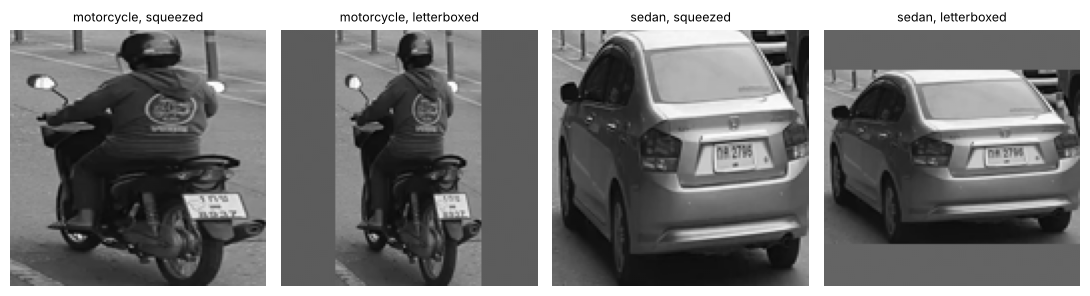

In [22]:
def load_letterbox(path, size=image_size):
    """Resize keeping the aspect ratio; the rest of the square is filled with the mean grey level."""
    with Image.open(path) as image:
        image = image.convert("L")
        scale = min(size[0] / image.width, size[1] / image.height)
        resized = image.resize((max(1, round(image.width * scale)),
                                max(1, round(image.height * scale))))
        canvas = Image.new("L", size, int(round(np.asarray(resized).mean())))
        canvas.paste(resized, ((size[0] - resized.width) // 2, (size[1] - resized.height) // 2))
        return np.asarray(canvas, dtype=np.float64) / 255.0


def recall_summary(predicted):
    """Overall accuracy, motorcycle recall and mean recall over the four car classes."""
    recall = {label: np.mean(predicted[subset_labels == label] == label)
              for label in np.unique(subset_labels)}
    cars = np.mean([value for label, value in recall.items() if label != "motorcycle"])
    return np.mean(predicted == subset_labels), recall["motorcycle"], cars


print("Share of images taller than wide, and median width / height")
for label in np.unique(subset_labels):
    ratio = subset_aspect[subset_labels == label]
    print(f"  {label:11s} {np.mean(ratio < 1):6.1%}   {np.median(ratio):.2f}")

# 1. Aspect ratio alone: leave-one-out 1-NN on log(width / height).
log_aspect = np.log(subset_aspect)
distance = np.abs(log_aspect[:, None] - log_aspect[None, :])
np.fill_diagonal(distance, np.inf)
aspect_predicted = subset_labels[distance.argmin(axis=1)]

# 2. The same descriptor on squeezed and on letterboxed images.
letterboxed = np.stack([load_letterbox(path) for path in subset_paths])
rows = [("aspect ratio only", None, aspect_predicted)]
for cell in (8, 16):
    squeezed = predictions[("Cell size", cell)]
    _, _, boxed = evaluate(np.stack([hog(image, cell=cell) for image in letterboxed]))
    p, _, _ = mcnemar(squeezed == subset_labels, boxed == subset_labels)
    rows.append((f"HOG cell {cell}, squeezed", None, squeezed))
    rows.append((f"HOG cell {cell}, letterboxed", p, boxed))

print(f"\n{'Input':28s} {'Accuracy':>9s} {'Motorcycle':>11s} {'Car classes':>12s} {'p vs squeezed':>14s}")
for label, p, predicted in rows:
    accuracy, motorcycle, cars = recall_summary(predicted)
    p_text = "" if p is None else f"{p:14.3f}"
    print(f"{label:28s} {accuracy:9.3f} {motorcycle:11.2f} {cars:12.3f} {p_text}")

fig, axes = plt.subplots(1, 4, figsize=(11, 3), squeeze=False)
example = int(np.flatnonzero(subset_labels == "motorcycle")[0])
other = int(np.flatnonzero(subset_labels == "sedan")[0])
for ax, (image, title) in zip(axes[0], [(subset_images[example], "motorcycle, squeezed"),
                                        (letterboxed[example], "motorcycle, letterboxed"),
                                        (subset_images[other], "sedan, squeezed"),
                                        (letterboxed[other], "sedan, letterboxed")]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**The aspect ratio alone finds the motorcycles.** 97.5 % of the motorcycle images are taller than
wide, against 0 to 7.5 % in the car classes. A nearest-neighbour rule that sees nothing but
width / height gets a motorcycle recall of 0.93, and 0.275 on the four car classes, which is close
to guessing. Motorcycle recall in this notebook is therefore not evidence about HOG. The honest
figure for the descriptor is the mean recall over the four car classes: 0.72 at cell 8 and 0.76 at
cell 16.

**Letterboxing does not remove the cue, and it costs on the cars.** The grey bars are themselves a
picture of the aspect ratio, so motorcycle recall stays at 0.93. On the car classes recall falls
from 0.719 to 0.688 at cell 8, which is within noise ($p = 0.87$ on all five classes), and from
0.762 to 0.669 at cell 16, where overall accuracy drops from 0.790 to 0.720 ($p = 0.024$, one of two
tests, so suggestive rather than settled). A likely reason, which we have not tested separately, is size: a letterboxed
landscape image fills only about 128 x 90 pixels, so the vehicle is smaller and a 16 pixel cell
covers a larger part of it.

Two things follow. The advantage of the coarse cell found above belongs to squeezed images, where
the vehicle fills the frame; it is a statement about cell size relative to object size, not about
16 pixels as such. And we keep squeezing even though it lets the aspect ratio leak into the descriptor, for two
reasons: letterboxing leaks it just as much, and squeezing gives the higher recall on the car
classes, where the aspect ratio does not help. The leak is handled in the reporting instead, by
giving the car classes separately and comparing motorcycle results with the aspect-ratio baseline.


### Does L1 hold at the cell size we choose?

L1 normalisation came out ahead of L2-Hys at the baseline cell size, with an accuracy difference
that did not survive the correction for multiple tests. A result of that kind should be tried again
under different conditions before it is acted on, so we repeat the comparison at 16 x 16 cells, the
size we are about to choose. This is one planned test, not one of many.


In [23]:
print(f"{'Cell':>5s} {'Norm':8s} {'Gap':>7s} {'Accuracy':>9s} {'Car classes':>12s} "
      f"{'p vs L2-Hys':>12s} {'Gap difference, 95 % interval':>32s}")
for cell in (8, 16):
    gap_ref, _, predicted_ref = evaluate(np.stack([hog(x, cell=cell) for x in subset_images]),
                                         ("L2-Hys", cell))
    gap_l1, _, predicted_l1 = evaluate(np.stack([hog(x, cell=cell, norm="L1") for x in subset_images]),
                                       ("L1", cell))
    p, _, _ = mcnemar(predicted_ref == subset_labels, predicted_l1 == subset_labels)
    difference = np.array([gap_on(similarities[("L1", cell)], r)
                           - gap_on(similarities[("L2-Hys", cell)], r) for r in resamples])
    low, high = np.percentile(difference, [2.5, 97.5])
    for norm, gap, predicted, tail in [
            ("L2-Hys", gap_ref, predicted_ref, ""),
            ("L1", gap_l1, predicted_l1,
             f"{p:12.3f} {gap_l1 - gap_ref:+11.4f} [{low:+.4f}, {high:+.4f}]")]:
        accuracy, _, cars = recall_summary(predicted)
        print(f"{cell:5d} {norm:8s} {gap:7.4f} {accuracy:9.3f} {cars:12.3f} {tail}")

 Cell Norm         Gap  Accuracy  Car classes  p vs L2-Hys    Gap difference, 95 % interval
    8 L2-Hys    0.0266     0.745        0.719 
    8 L1        0.0361     0.800        0.781        0.019     +0.0095 [+0.0073, +0.0118]
   16 L2-Hys    0.0299     0.790        0.762 
   16 L1        0.0411     0.810        0.787        0.503     +0.0112 [+0.0085, +0.0143]


The advantage in cosine gap repeats: +0.0095 at cell 8 and +0.0112 at cell 16, both with intervals
far from zero. The advantage in accuracy does not repeat at the same strength. At cell 16 L1 gains
four images, 0.810 against 0.790, with $p = 0.50$, where it gained eleven at cell 8.

So L1 separates the classes better on average at both cell sizes, and is never worse in accuracy,
but the large accuracy gain at cell 8 was partly luck, as the correction for multiple tests
suggested. Because L1 costs nothing, the descriptor has the same length and takes the same time to
compute, consistent evidence in one direction is enough to adopt it. A change that doubled the
length would need the accuracy to confirm it.


### Choice of parameters

No accuracy difference between parameter settings survives the paired test (all $p > 0.10$). The
cosine gap differences are stable under the bootstrap, so the gap is used to rank the settings, with
the reservation that accuracy does not show the ranking to have a practical effect at this sample
size.

| Parameter | Gap | Reading |
|---|---|---|
| Cell 4, 8, 16, 32 | 0.020, 0.027, **0.030**, 0.019 | optimum in the middle |
| Block 1, 2, 3 | 0.015, 0.027, **0.033** | overlap helps, at a cost in length |
| Bins 4, 9, 12, 18 | 0.016, 0.027, 0.028, **0.030** | 4 too coarse, nearly flat from 9 |
| Unsigned / signed | **0.027** / 0.024 | keeping the polarity loses a little |
| L2-Hys / L1 | 0.027 / **0.036** | L1 ahead, and again at cell 16 (0.030 / 0.041) |

**Cell size** changes the descriptor most. Fine cells ask "is there a diagonal edge exactly here",
which changes when the same car is photographed further away, and they cost length: 34 596 values at
cell 4 against 8 100 at cell 8. Coarse cells leave only 4 x 4 cells at cell 32 and the descriptor
becomes a rough sketch of the outline, as the cell size figure shows.

**Block size** does not change the cells, only how often each one is used and what it is normalised
against. With one cell per block every cell is normalised alone, a weak cell is stretched as far as
a strong one, and the gap is lowest. With 3 x 3 blocks every interior cell appears nine times, each
time normalised against a different neighbourhood; the gap is highest and the descriptor is almost
twice as long as with 2 x 2.

**Bins** trade angular resolution against the number of pixels behind each bin. With four bins of 45
degrees the segments in the figure collapse to crosses and a 100 degree and a 130 degree edge vote
for the same bin. With 18 bins neighbouring segments nearly coincide: the 64 pixels of a cell are
spread over twice as many bins, and the gain over nine bins is +0.003 for a descriptor twice as
long.

**We choose cell 16, block 2, 9 bins, unsigned, with L1 block normalisation**, giving 1 764 values
per image instead of 8 100.
Cell 16 has the highest gap of the four cell sizes, the highest accuracy, and a descriptor 4.6 times
shorter, with the reservation from the aspect-ratio check that this holds for squeezed images in
which the vehicle fills the frame. Block 3 and 18 bins both raise the gap further but roughly double
the length for a gain accuracy cannot confirm, so we stay with block 2 and 9 bins.

**Normalisation.** We replace L2-Hys with L1. It has the largest gain in cosine gap of all the
settings tried, the gain repeats at the chosen cell size, accuracy points the same way at both cell
sizes (+5.5 and +2.0 points) without being resolved, and it costs nothing in length or time. The
experiments in this notebook keep L2-Hys as their baseline, because that is the published
configuration and the default of the library, so every comparison above refers to it.

**Signed gradients.** Keeping the polarity lowers the gap slightly. A plausible reason is that the
same vehicle type comes in light and dark paint, which flips the sign of its edges against the
road, but we have not tested that explanation.

**Caveat.** Motorcycle recall rises from 0.85 at cell 8 to 1.00 at cell 32, but the aspect-ratio
check above shows that motorcycles are found from the shape of the image alone. Any motorcycle
result on this dataset has to be compared with that baseline.

## Where the task is answered

| Task | Section |
|---|---|
| 1. Script that computes the HOG features, using a library | *HOG Features with scikit-image*: `compute_hog` calls `skimage.feature.hog` |
| 2. At least three images, simple and complex scenes | *Dataset and preparation*: a silhouette and four vehicle scenes of increasing complexity |
| 3. Original image, gradient image and HOG feature image | *Gradient Computation* and *Visualization* |
| 4. Compare the HOG features of the images | *Comparing the Images* |
| 4. Impact of cell size, block size and number of bins | *Experimentation*, *How stable is the cosine gap?* and *Choice of parameters* |
| Dataset description | *Dataset and preparation* |
| Beyond the task | *Our Own Implementation* and *Comparison with scikit-image* (exact match with single-bin voting), *Block Normalisation*, *Two Choices Taken from the Paper*, *How much of this is the aspect ratio?*, *Does L1 hold at the cell size we choose?* |
